# Tropical Pacific SST contrast, 1950–2025

**Question:** How has the difference between western and eastern equatorial Pacific sea-surface temperature changed, and how sensitive are its estimated trends to reasonable analysis choices?

This executed notebook uses **real monthly ERSSTv5 and COBE-SST2 data**, supplied through NOAA PSL. It builds an observational index, estimates trends and investigates uncertainty. It does not estimate a forced response or establish a climate mechanism.

The cells below show the calculations, intermediate results, and methods.

**How to read:** a regional temperature is an area mean; the gradient index is the western mean minus the eastern mean; a trend measures how that difference changes per decade. The notebook exposes intermediate calculations, not only final figures.

## 1. Locate the repository and verify the input snapshot

The small data files are bundled. Their SHA-256 hashes identify the exact bytes used. A live NOAA update must not silently change an otherwise identical analysis. The pipeline therefore verifies the files before calculating anything.

Run the notebook from the project root or its `notebooks` folder, using the environment described in the README.

In [1]:
from pathlib import Path
import sys, json, subprocess
import numpy as np
import pandas as pd
import xarray as xr
from IPython.display import display, Image, Markdown

ROOT = Path.cwd()
if not (ROOT / "config.json").exists() and (ROOT.parent / "config.json").exists():
    ROOT = ROOT.parent
assert (ROOT / "config.json").exists(), "Open the notebook inside the repository."
sys.path.insert(0, str(ROOT))
from src.sst_gradient import load_sst, box_mean, annual_mean, trend_interval, residual_acf
from scripts.download_data import verify_inputs, SOURCES

config = json.loads((ROOT / "config.json").read_text())
manifest = verify_inputs()
display(pd.DataFrame([{k: r[k] for k in ["source", "size_bytes", "first_month", "last_month", "sha256"]}
                      for r in manifest["files"]]))

,source,size_bytes,first_month,last_month,sha256
0,ERSSTv5,1955356,1950-01-01,2026-01-01,aded7fdff16d6adbf42d11e594d74428218e6aed3ca9e6...
1,COBE-SST2,7171404,1950-01-01,2025-12-01,5a7d13f857ba3d80900933189886b975bfe2268162e3ef...


The ERSST download service returned one extra month, January 2026. `load_sst` explicitly clips both products to January 1950–December 2025. No 2026 data enter the results.

ERSSTv5 is a specified previous version, chosen for comparability with the motivating literature. ERSSTv6 is available but is not analysed here. The two products use overlapping observations, so agreement between them is not independent replication.

In [2]:
sst = {name: load_sst(ROOT / "data/raw" / spec["file"], config["start_year"], config["end_year"])
       for name, spec in SOURCES.items()}
display(pd.DataFrame([{"dataset": name, "months": da.sizes["time"],
                       "first": str(da.time.values[0])[:10], "last": str(da.time.values[-1])[:10],
                       "latitude_spacing_deg": float(da.lat[1]-da.lat[0]),
                       "longitude_spacing_deg": float(da.lon[1]-da.lon[0]), "units": da.attrs["units"]}
                      for name, da in sst.items()]))
assert all(da.sizes["time"] == 912 for da in sst.values())

,dataset,months,first,last,latitude_spacing_deg,longitude_spacing_deg,units
0,ERSSTv5,912,1950-01-01,2025-12-01,2.0,2.0,degC
1,COBE-SST2,912,1950-01-01,2025-12-01,1.0,1.0,degC


## 2. Define two physical regions

The primary western box is **140–170°E, 3°S–3°N**; the eastern box is **190–270°E, 3°S–3°N**. The latter is also written 170–90°W.

The index is $G(t)=T_W(t)-T_E(t)$, in **°C**, not °C per kilometre. Positive $G$ means the western box is warmer. Positive change in $G$ means the contrast increases.

Use a native-grid area mean with partial boundary cells. For the part of a cell inside the box, the weight is proportional to $\Delta\lambda[\sin(\phi_N)-\sin(\phi_S)]$. Each regional mean is normalized separately. A fixed mask prevents changes in usable grid cells from becoming a false temperature signal.

In [3]:
west, west_info, west_weights = box_mean(sst["ERSSTv5"], (-3, 3), config["west"])
east, east_info, east_weights = box_mean(sst["ERSSTv5"], (-3, 3), config["east"])
monthly_example = pd.DataFrame({"west": west, "east": east})
monthly_example["gradient"] = monthly_example.west - monthly_example.east
display(monthly_example.head())
display(pd.DataFrame([{"region": "west", **west_info}, {"region": "east", **east_info}]))

# Independent, explicit check of the first monthly western mean.
first_field = sst["ERSSTv5"].isel(time=0).values
weights = west_weights.values
manual = np.sum(np.where(np.isfinite(first_field), first_field, 0)*weights)/weights.sum()
np.testing.assert_allclose(manual, west.iloc[0], rtol=0, atol=1e-10)
print(f"January 1950 western SST: {manual:.6f} °C (manual calculation agrees)")

January 1950 western SST: 28.586388 °C (manual calculation agrees)


,west,east,gradient
time,,,
1950-01-01,28.586388,23.629456,4.956932
1950-02-01,28.471821,24.704008,3.767813
1950-03-01,28.433784,25.979134,2.454650
1950-04-01,28.561961,26.073326,2.488635
1950-05-01,28.717237,25.626262,3.090975


,region,retained_cells,overlap_cells,valid_area_steradians,valid_fraction_of_geometric_box
0,west,48,48,0.054806,1.0
1,east,123,123,0.146150,1.0


The coverage fraction describes the finite cells in a reconstructed field. It does not mean every cell was directly observed each month. In the wider ±5° western box, each product also has its own land mask.

## 3. Average months into complete years

Month lengths differ. Weight January by 31 days and February by 28 or 29. Require twelve unique months in each year. The code rejects incomplete years rather than quietly comparing them with full years.

The baseline used in the figures is the mean of annual values in 1981–2010. Subtracting a constant baseline changes the zero point, not the trend.

In [4]:
annual_example = annual_mean(monthly_example)
# Check the leap year 2000 explicitly.
m2000 = monthly_example.loc["2000"]
manual_annual = np.average(m2000["gradient"], weights=m2000.index.days_in_month)
np.testing.assert_allclose(manual_annual, annual_example.loc[2000, "gradient"], atol=1e-12)
assert np.asarray(m2000.index.days_in_month).sum() == 366
print(f"2000 contrast: {manual_annual:.6f} °C, averaged over 366 days")
display(annual_example.head())

2000 contrast: 3.902992 °C, averaged over 366 days


,west,east,gradient
year,,,
1950,28.712404,24.889998,3.822406
1951,28.912007,26.306517,2.605490
1952,28.821778,25.644513,3.177265
1953,28.840944,26.390093,2.450851
1954,28.813702,24.944299,3.869403


## 4. Reproduce all products, periods and figures

This call runs the same public script as the command-line workflow. It creates monthly and annual CSVs, retained spatial weights, coverage statistics, 80 trend/interval estimates and five figures in PNG and PDF.

The default periods and latitude bands were fixed before computing the results. Alternative windows are reported as sensitivity checks, without selecting only the most striking estimate.

# Computed results

Units: °C per decade. Primary latitude band: 3°S–3°N.

Intervals: 95% percentile circular residual-block bootstrap, 5-year blocks, 5,000 draws.

| Dataset | Period | West − east trend | 95% interval |
|---|---|---:|---:|
| ERSSTv5 | 1950–2025 | +0.076 | [+0.022, +0.128] |
| ERSSTv5 | 1979–2025 | +0.183 | [+0.081, +0.279] |
| COBE-SST2 | 1950–2025 | +0.076 | [+0.021, +0.130] |
| COBE-SST2 | 1979–2025 | +0.184 | [+0.084, +0.281] |

See trends.csv for western and eastern component trends, both latitude bands, all four periods and three block lengths.

These are descriptive observational trends. They neither identify a forced response nor establish mechanisms.
The two reconstructions share observations. Bootstrap intervals do not include all observational or reconstruction uncertainty.

Saved 3,648 monthly rows, 304 annual rows and 80 trend estimates.



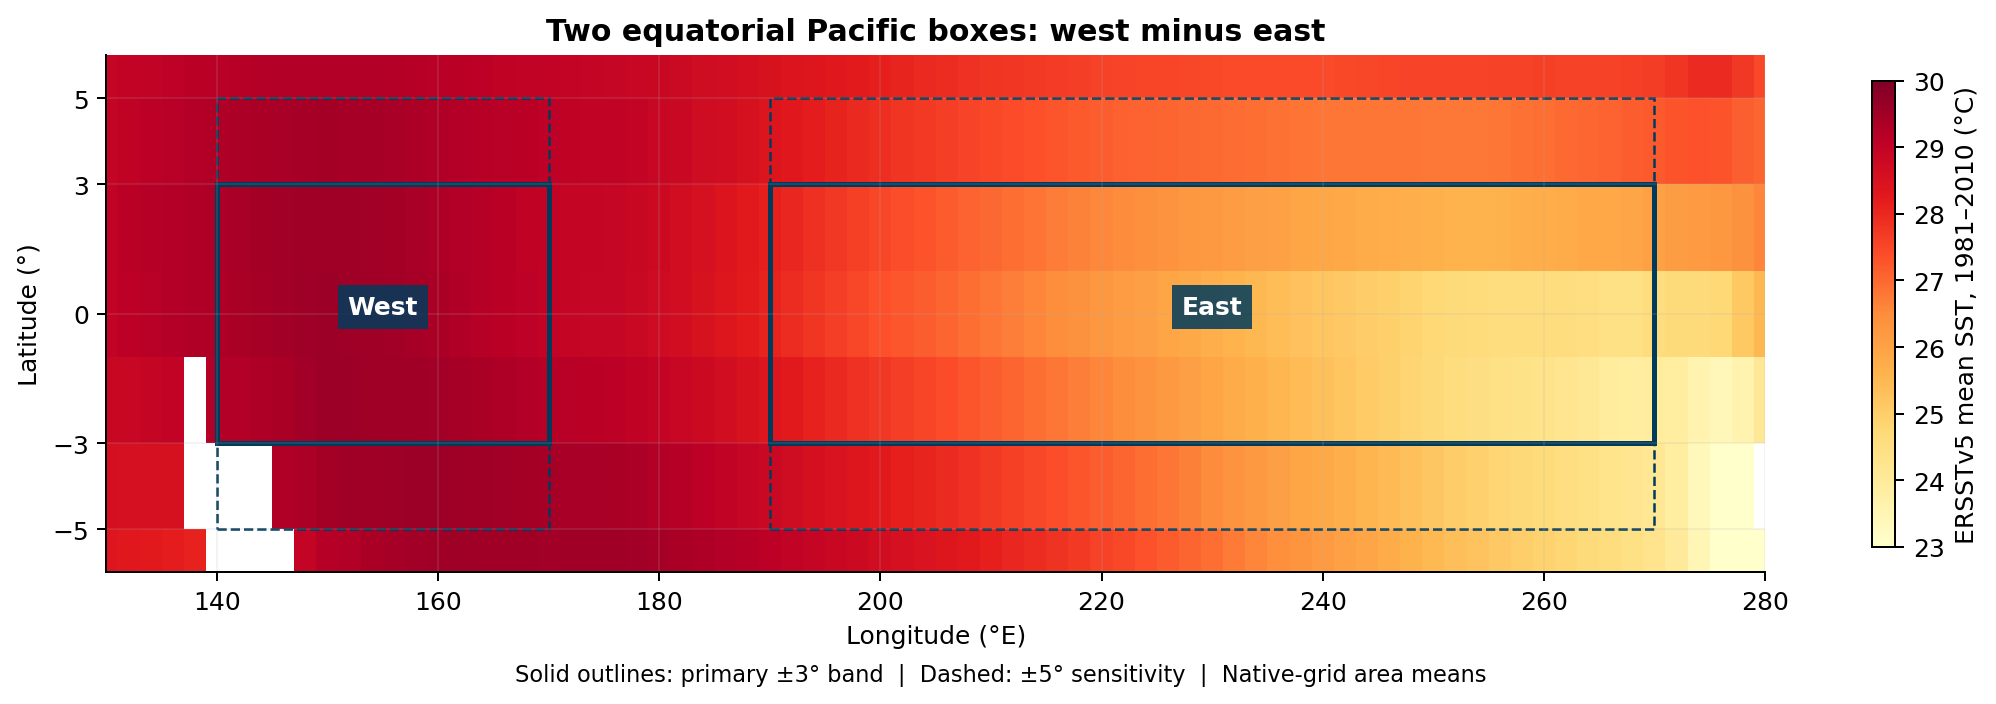

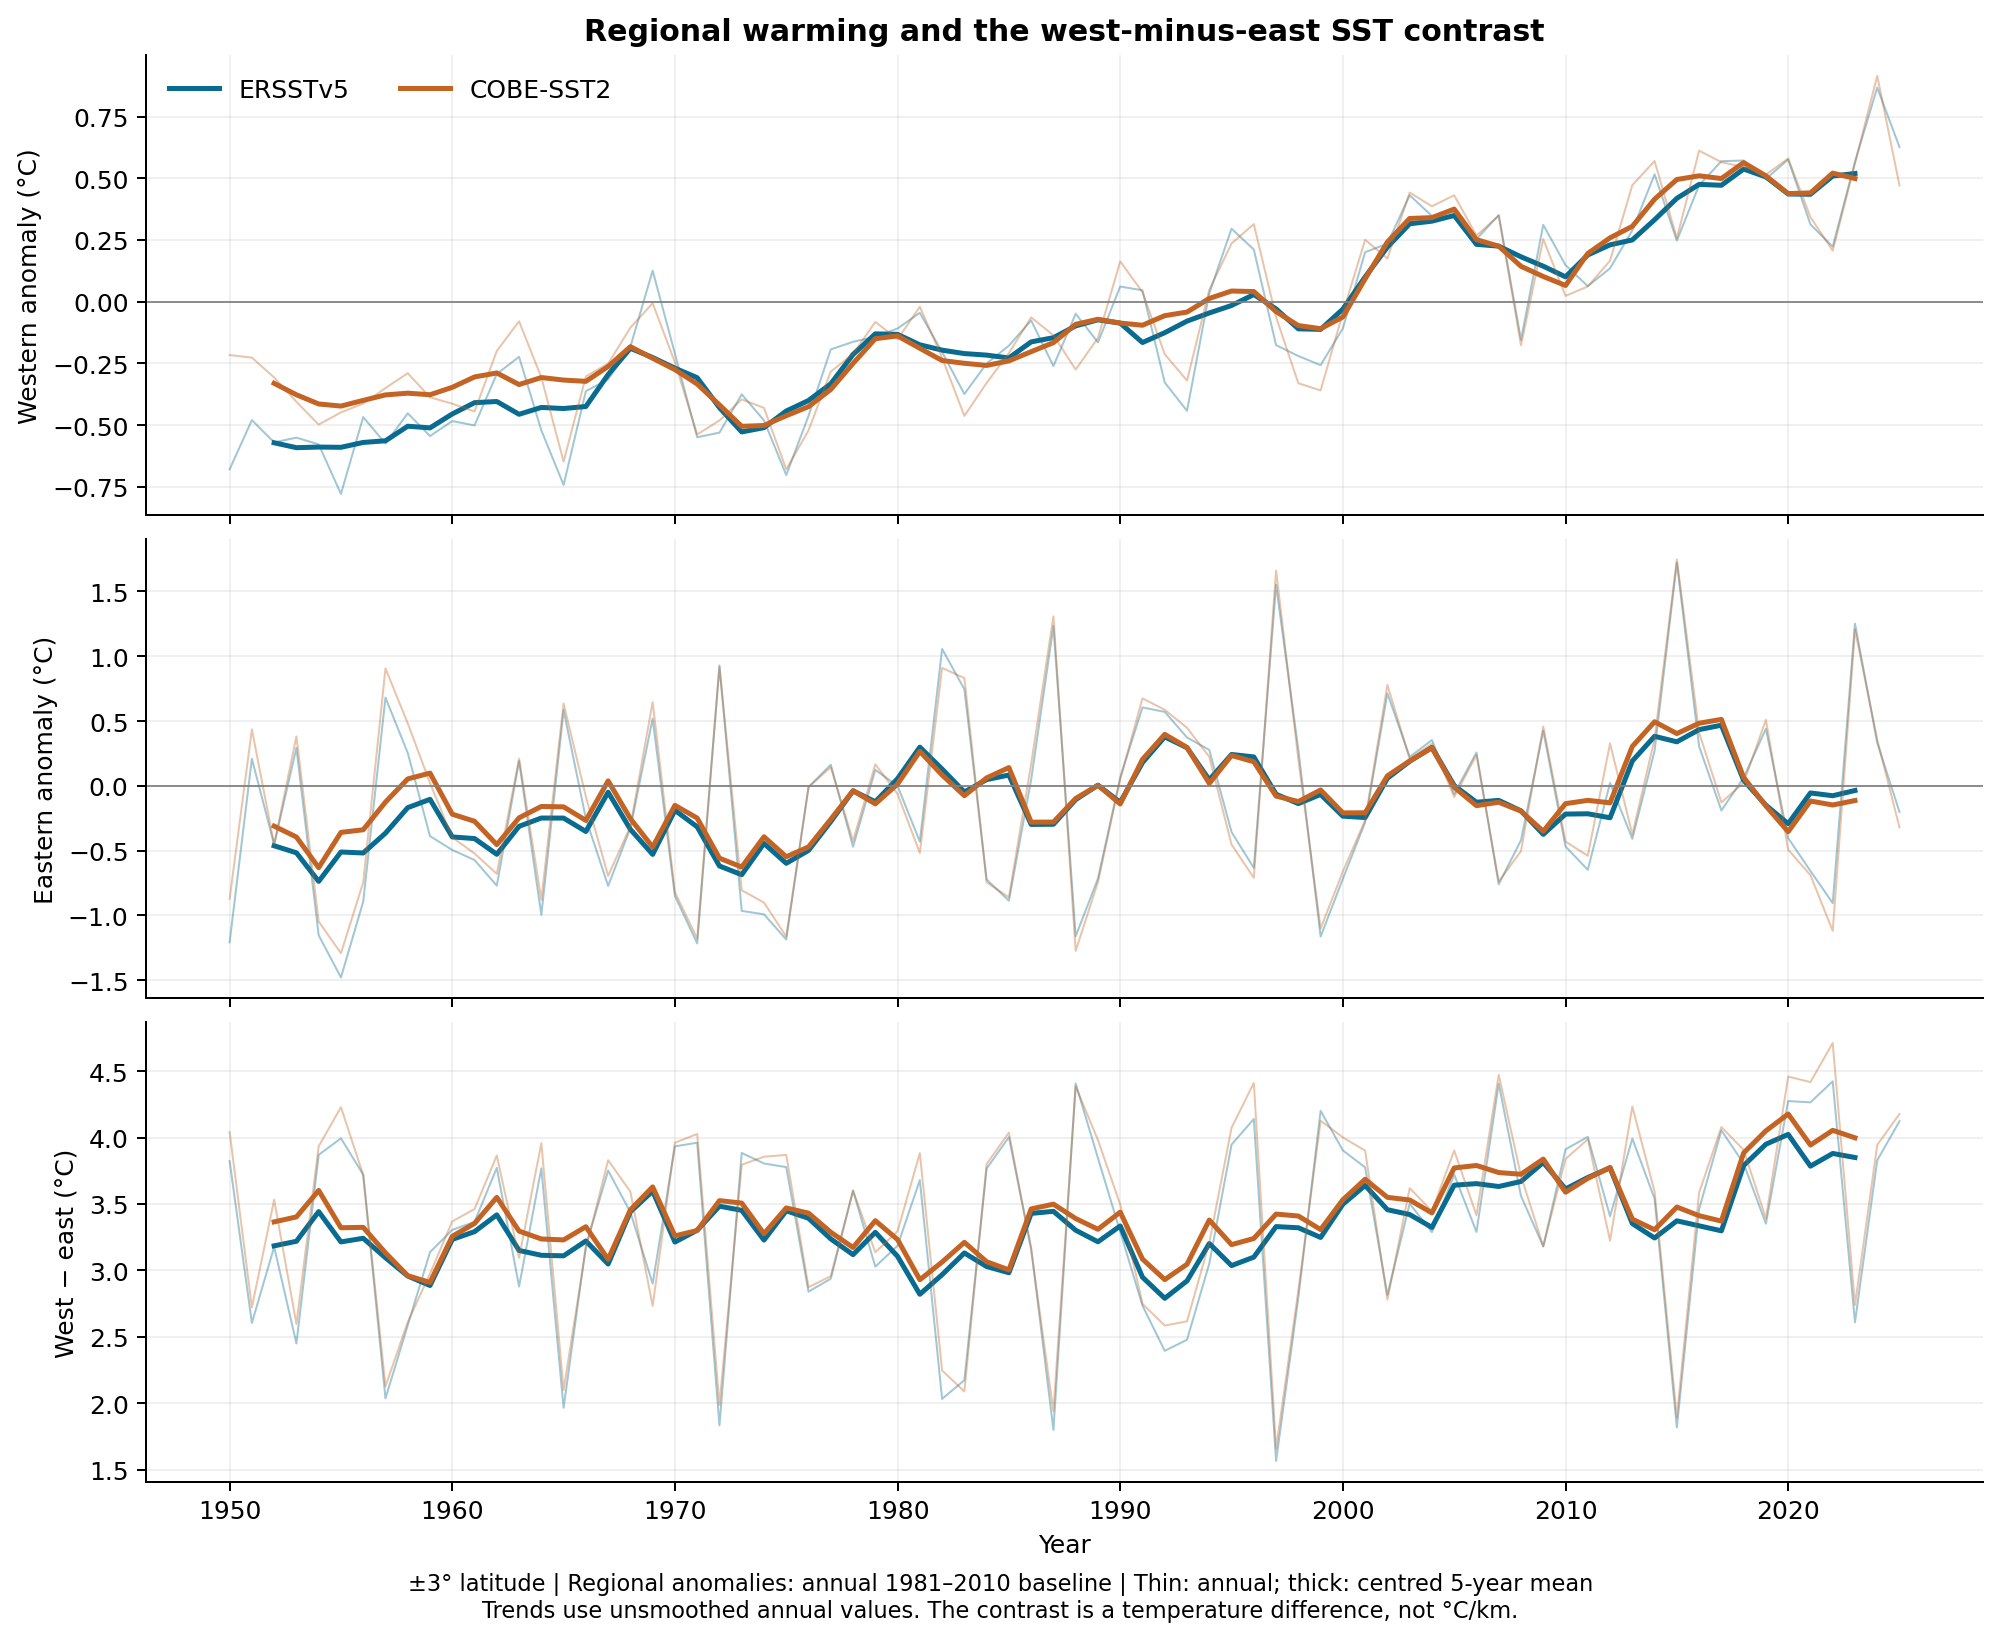

In [5]:
completed = subprocess.run([sys.executable, str(ROOT / "scripts/run_analysis.py")],
                           cwd=ROOT, check=True, capture_output=True, text=True)
print(completed.stdout)
annual = pd.read_csv(ROOT / "data/processed/annual_indices.csv")
trends = pd.read_csv(ROOT / "results/trends.csv")
display(Image(filename=str(ROOT / "figures/01_regions.png"), width=1000))
display(Image(filename=str(ROOT / "figures/02_time_series.png"), width=1000))

Read the thin annual lines before the smoothed ones. A straight trend is a summary of a noisy time series. The five-year smoother helps viewing but is not used for estimation, and its full-window requirement removes its first and last two years.

The eastern series has large interannual changes. The gradient also has substantial variability: the fitted long-term line explains only a small fraction of its annual variance. A positive slope does not mean it increased every year.

## 5. Estimate trends and preserve short-term dependence

Ordinary least squares fits an intercept and a slope to **unsmoothed annual** values. The slope per year is multiplied by ten to obtain °C per decade.

For uncertainty, subtract the fitted line, sample blocks of consecutive residuals, add them back to the fitted line and refit. Blocks wrap around the residual record. Use 5,000 resamples, five-year blocks and a fixed seed. This keeps some neighbouring-year dependence instead of pretending every year is unrelated.

The resulting 95% percentile interval is conditional on the observed record, linear trend and resampling assumptions. It is not a complete uncertainty budget. Longer-lived variability, measurement biases and reconstruction uncertainty can remain.

slope_C_per_decade       0.075865
ci_low                   0.022116
ci_high                  0.128072
n_years                 76.000000
block_years              5.000000
bootstrap_draws       5000.000000
r_squared                0.056120
Name: ERSSTv5 gradient, 1950–2025, dtype: float64

,dataset,start_year,end_year,variable,slope_C_per_decade,ci_low,ci_high
0,ERSSTv5,1950,2025,west,0.1566,0.1338,0.1789
1,ERSSTv5,1950,2025,east,0.0808,0.0278,0.1349
3,ERSSTv5,1950,2025,gradient,0.0759,0.0221,0.1281
5,ERSSTv5,1979,2025,west,0.1840,0.1395,0.2263
6,ERSSTv5,1979,2025,east,0.0005,-0.1042,0.1067
8,ERSSTv5,1979,2025,gradient,0.1835,0.0814,0.2788
40,COBE-SST2,1950,2025,west,0.1339,0.1043,0.1638
41,COBE-SST2,1950,2025,east,0.0583,0.0046,0.1116
43,COBE-SST2,1950,2025,gradient,0.0757,0.0208,0.1298
45,COBE-SST2,1979,2025,west,0.1858,0.1388,0.2305


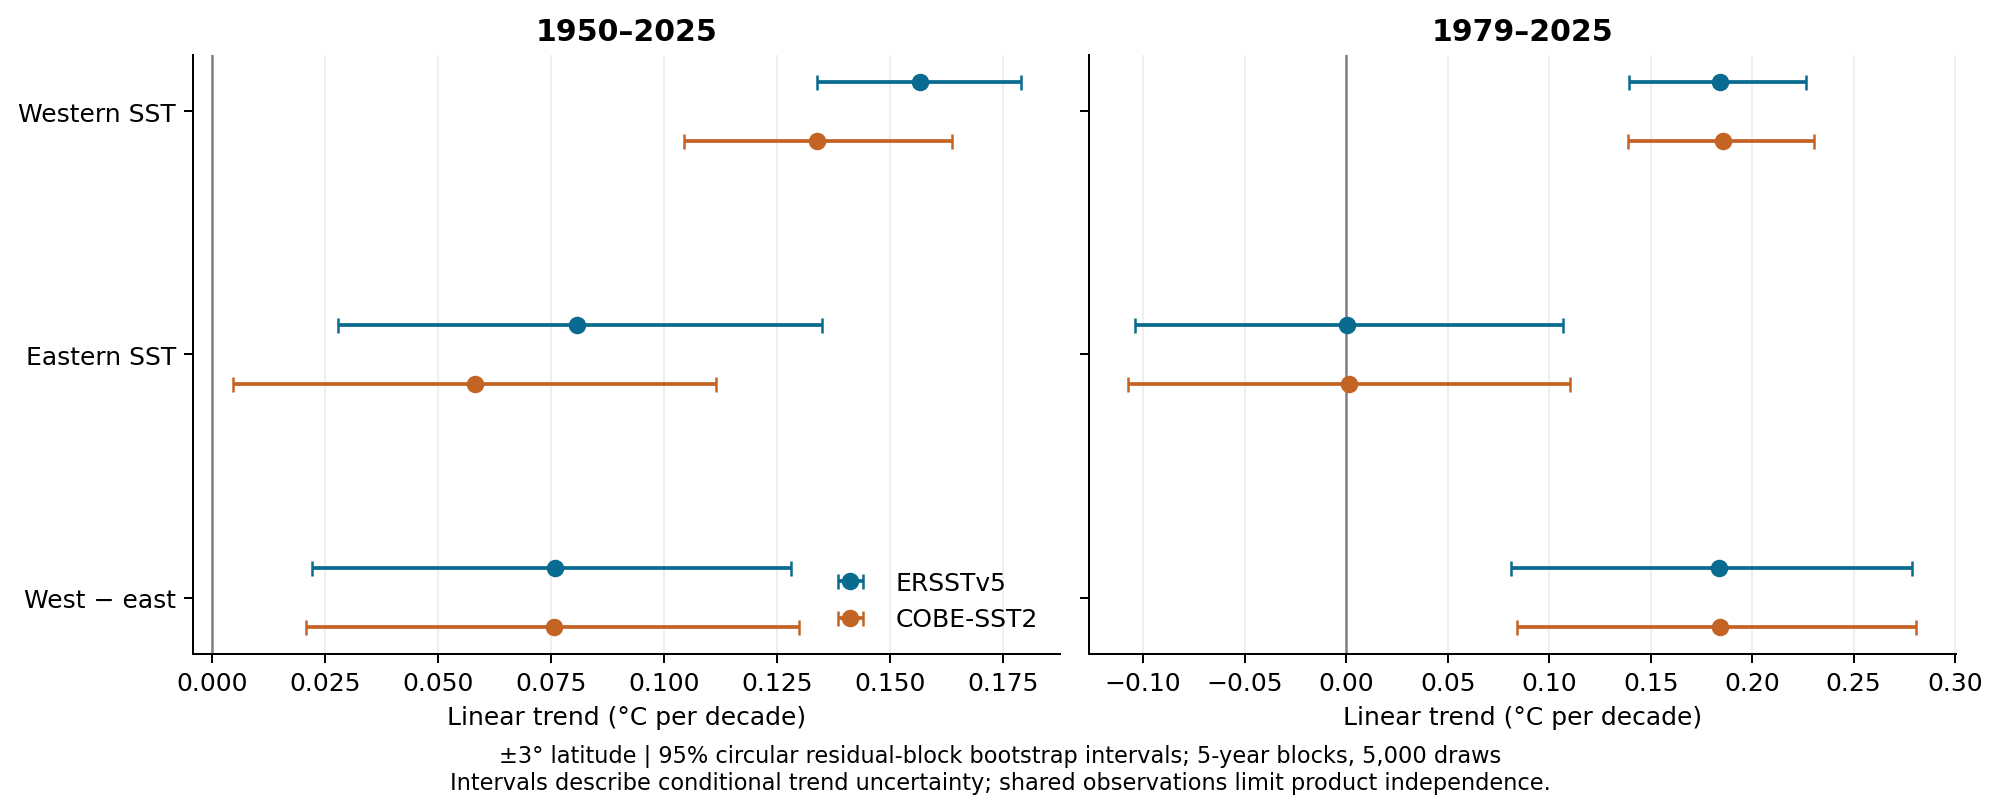

In [6]:
example_result = trend_interval(annual_example.index, annual_example.gradient,
                                block=5, draws=5000, seed=config["seed"])
display(pd.Series(example_result, name="ERSSTv5 gradient, 1950–2025"))

# Subtracting a constant baseline must leave the fitted slope unchanged.
baseline = annual_example.loc[1981:2010, "gradient"].mean()
shifted = trend_interval(annual_example.index, annual_example.gradient-baseline,
                        block=5, draws=5000, seed=config["seed"])
np.testing.assert_allclose(example_result["slope_C_per_decade"], shifted["slope_C_per_decade"], atol=1e-12)

primary = trends[(trends.latitude_half_width == 3) & (trends.block_years == 5)
                 & trends.start_year.isin([1950, 1979])]
display(primary[["dataset", "start_year", "end_year", "variable", "slope_C_per_decade", "ci_low", "ci_high"]].round(4))
display(Image(filename=str(ROOT / "figures/03_primary_trends.png"), width=1000))

**What the primary results support:**

- Over 1950–2025, the contrast increases by about **0.076°C per decade** in each product. Both western and eastern boxes warm; western warming is faster.
- Over 1979–2025, the contrast increases by about **0.183–0.184°C per decade**. Eastern trend estimates are close to zero and their intervals include warming and cooling.
- These are descriptions of regional SST, not evidence by themselves of anthropogenic attribution, model failure, stronger trade winds or thermocline changes.

The periods overlap. Different estimates are not, by themselves, a statistical demonstration of acceleration.

## 6. Check sensitivity rather than relying on one answer

Compare both latitude bands, all four specified periods and gradient block lengths of 3, 5 and 7 years. Short windows can be strongly affected by their endpoints and natural variability. The products share observations and their intervals are not independent tests.

,dataset,latitude_half_width,start_year,slope_C_per_decade,ci_low,ci_high
3,ERSSTv5,3,1950,0.0759,0.0221,0.1281
8,ERSSTv5,3,1979,0.1835,0.0814,0.2788
13,ERSSTv5,3,1993,0.2041,0.0283,0.3784
18,ERSSTv5,3,2000,0.1165,-0.1170,0.3549
23,ERSSTv5,5,1950,0.0739,0.0214,0.1252
28,ERSSTv5,5,1979,0.1826,0.0832,0.2753
33,ERSSTv5,5,1993,0.2050,0.0366,0.3736
38,ERSSTv5,5,2000,0.1077,-0.1144,0.3403
43,COBE-SST2,3,1950,0.0757,0.0208,0.1298
48,COBE-SST2,3,1979,0.1844,0.0842,0.2808


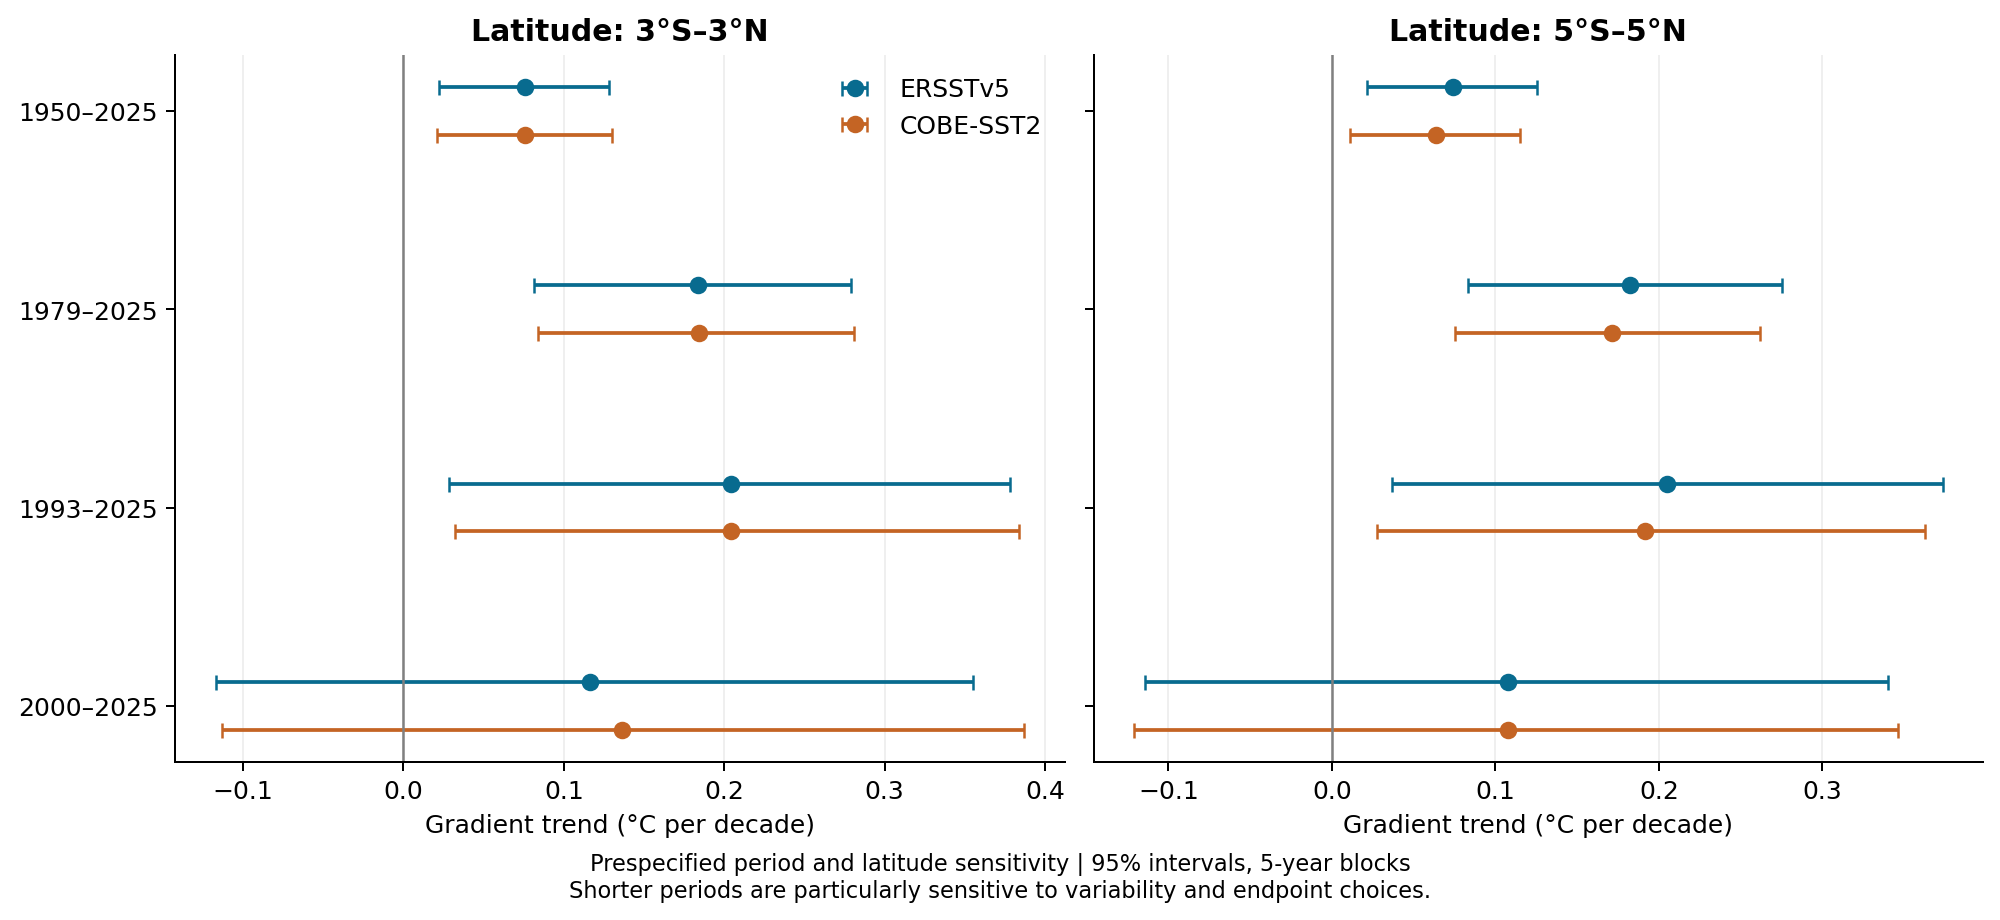

,dataset,start_year,block_years,ci_low,ci_high
2,ERSSTv5,1950,3,0.0154,0.1386
3,ERSSTv5,1950,5,0.0221,0.1281
4,ERSSTv5,1950,7,0.0261,0.1268
7,ERSSTv5,1979,3,0.0598,0.3104
8,ERSSTv5,1979,5,0.0814,0.2788
9,ERSSTv5,1979,7,0.0923,0.2729
42,COBE-SST2,1950,3,0.0151,0.1381
43,COBE-SST2,1950,5,0.0208,0.1298
44,COBE-SST2,1950,7,0.0240,0.1280
47,COBE-SST2,1979,3,0.0591,0.3139


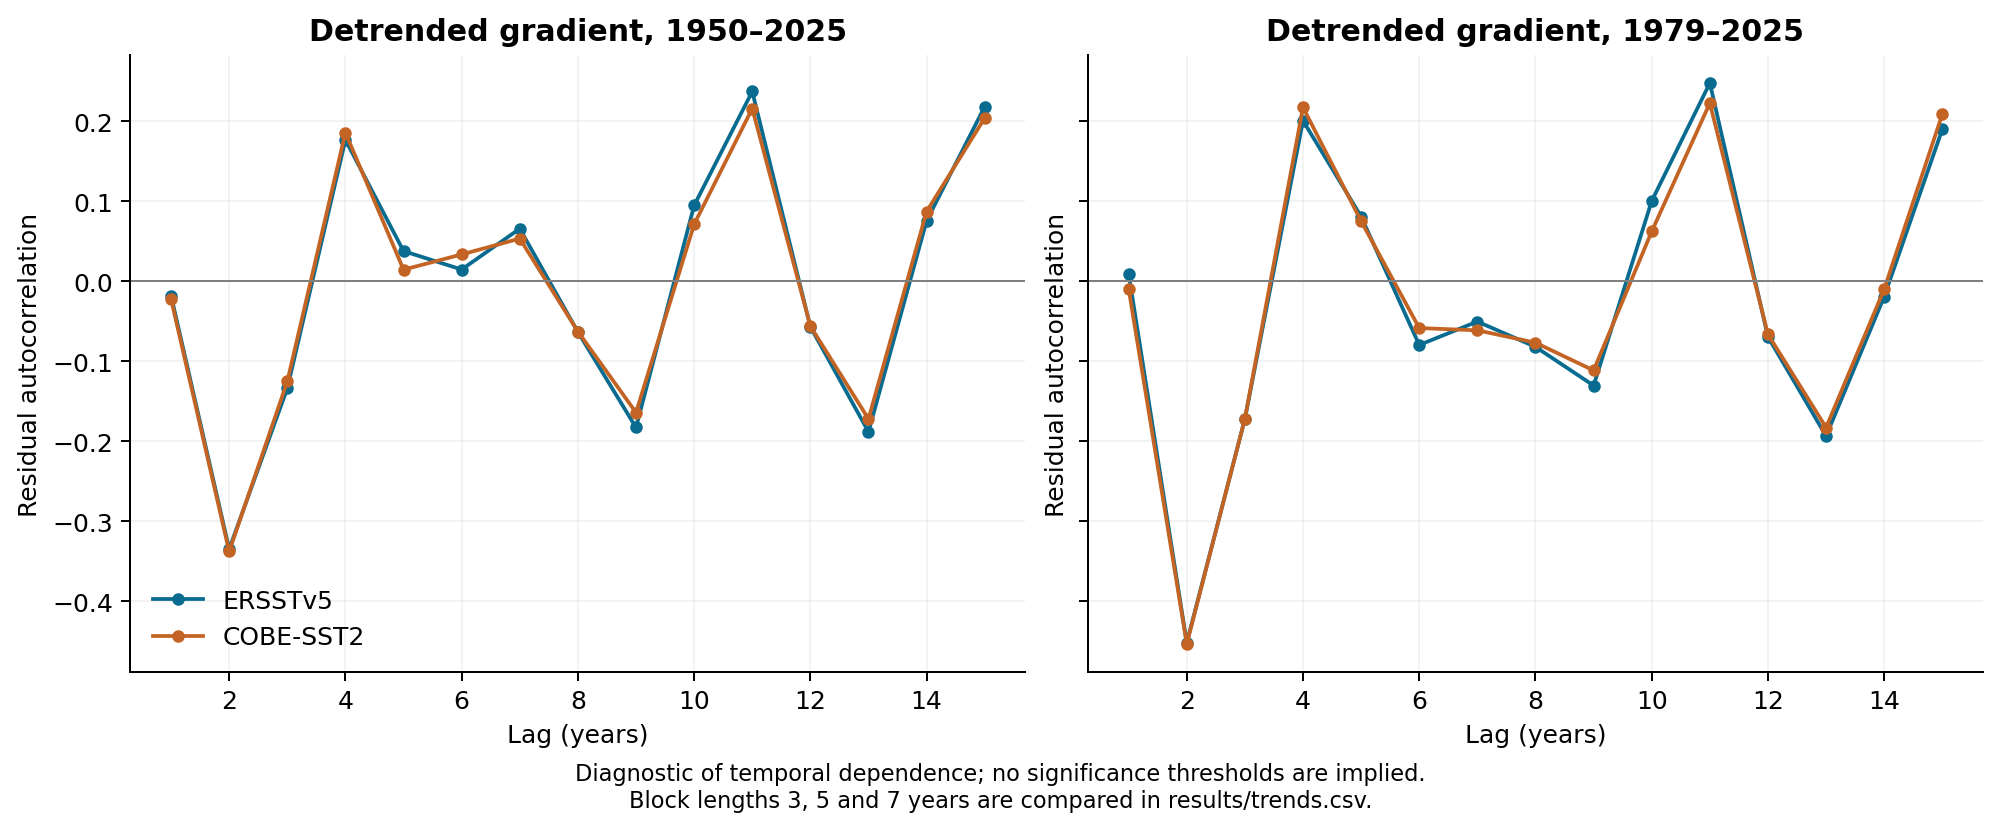

In [7]:
gradient = trends[trends.variable == "gradient"].copy()
display(gradient[gradient.block_years == 5][["dataset", "latitude_half_width", "start_year",
                                          "slope_C_per_decade", "ci_low", "ci_high"]].round(4))
display(Image(filename=str(ROOT / "figures/04_sensitivity.png"), width=1000))

# Block-length sensitivity for the primary latitude band and periods.
block_check = gradient[(gradient.latitude_half_width == 3) & gradient.start_year.isin([1950, 1979])]
display(block_check[["dataset", "start_year", "block_years", "ci_low", "ci_high"]].round(4))
display(Image(filename=str(ROOT / "figures/05_residual_dependence.png"), width=1000))

The 2000–2025 primary-band contrast intervals include zero for both products with five-year blocks. This is a reason to report period sensitivity, not to discard the shorter window.

Residual autocorrelation is a diagnostic, not proof that a particular block length is optimal. Blocks of a few years cannot fully represent multidecadal behaviour. There is no significance threshold on the autocorrelation figure and no claim of a joint confidence interval across all comparisons.

## 7. Check the calculations

The tests use synthetic fields with known answers: analytic area, boundary-cell splitting, coordinate conversion, fixed masks, complete months, leap years and an exactly known contrast trend. They also check deterministic resampling. Such checks detect programming errors; they do not establish that every physical or statistical assumption is appropriate.

In [8]:
checks = subprocess.run([sys.executable, "-m", "unittest", "discover", "-s", "tests", "-v"],
                        cwd=ROOT, check=True, capture_output=True, text=True)
print(checks.stdout + checks.stderr)

# Algebraic consistency in every product, band and period.
for keys, group in trends[trends.block_years == 5].groupby(["dataset", "latitude_half_width", "start_year"]):
    slopes = group.set_index("variable").slope_C_per_decade
    np.testing.assert_allclose(slopes["west"]-slopes["east"], slopes["gradient"], atol=2e-10)
print("All component trend identities agree.")

test_day_weighted_leap_year_and_incomplete_year (test_analysis.TestAnalysis.test_day_weighted_leap_year_and_incomplete_year) ... ok
test_grid_convention_and_constant_field (test_analysis.TestAnalysis.test_grid_convention_and_constant_field) ... ok
test_known_gradient_trend_and_bootstrap (test_analysis.TestAnalysis.test_known_gradient_trend_and_bootstrap) ... ok
test_missing_mask_is_explicit (test_analysis.TestAnalysis.test_missing_mask_is_explicit) ... ok
test_overlap_integrates_box_and_splits_boundary (test_analysis.TestAnalysis.test_overlap_integrates_box_and_splits_boundary) ... ok

----------------------------------------------------------------------
Ran 5 tests in 0.023s

OK

All component trend identities agree.


## 8. Potential extensions

A future project could add ERSSTv6 and independent wind-stress or upper-ocean diagnostics, then compare matching model ensembles. Those analyses are not part of this repository.

## References and data credit

- NOAA ERSSTv5: [dataset DOI](https://doi.org/10.7289/V5T72FNM); [Huang et al., 2017 methods](https://doi.org/10.1175/JCLI-D-16-0836.1).
- JMA COBE-SST2: [Hirahara, Ishii and Fukuda, 2014](https://doi.org/10.1175/JCLI-D-12-00837.1).
- Regional index and scientific context: [Byrne, Seager and Smerdon, Nature Communications 17, 142](https://doi.org/10.1038/s41467-025-66839-w). This notebook is not a replication of that paper's ensemble or attribution work.
- Data supplied through [NOAA Physical Sciences Laboratory](https://psl.noaa.gov/), Boulder, Colorado, USA. Exact source URLs and hashes are in `data/provenance.json`.

See `docs/METHODS.md` and `DATA_SOURCES.md` for full details.